In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qutip import *

In [8]:
tensor(basis(2,0),basis(2,0))

Quantum object: dims=[[2, 2], [1, 1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]]

In [9]:
tensor(sigmax(),sigmax())

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]]

In [23]:
H = tensor(sigmaz(),identity(2))+tensor(identity(2),sigmaz())-tensor(sigmay(),sigmay())+tensor(sigmax(),sigmax())

In [24]:
H

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 2.  0.  0.  2.]
 [ 0.  0.  0.  0.]
 [ 0.  0.  0.  0.]
 [ 2.  0.  0. -2.]]

In [25]:
H.ptrace(1)

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 2.  0.]
 [ 0. -2.]]

In [26]:
low_eng = Qobj([[2,0],[0,0]])

In [27]:
low_eng

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[2. 0.]
 [0. 0.]]

In [29]:
np.outer([1,0,0],[0,0,1])

array([[0, 0, 1],
       [0, 0, 0],
       [0, 0, 0]])

초기 결합 행렬:
[[0.5+0.j 0.1+0.j 0. +0.j 0. +0.j]
 [0.2+0.j 0.3+0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]]

연산 후 결과 행렬:
[[0.37258567+0.j 0.27538941+0.j 0.25919003+0.j 0.16199377+0.j]
 [0.3376947 +0.j 0.38504673+0.j 0.22679128+0.j 0.21183801+0.j]
 [0.25545171+0.j 0.18068536+0.j 0.17819315+0.j 0.10716511+0.j]
 [0.19190031+0.j 0.20685358+0.j 0.12959502+0.j 0.11464174+0.j]]
0 0
0 2
2 0
2 2
1 1
1 3
3 1
3 3

부분 트레이스 결과 (B에 대해):
[[0.7576324 +0.j 0.47102804+0.j]
 [0.4623053 +0.j 0.29283489+0.j]]

A의 원래 (0,0) 원소: (1+0j)
부분 트레이스 후 (0,0) 원소: (0.7576323987538938+0j)


In [35]:
from qutip import *
from scipy import *
from numpy import *

def qubit_integrate(w, theta, gamma1, gamma2, psi0, tlist):
    # operators and the hamiltonian
    sx = sigmax(); sy = sigmay(); sz = sigmaz(); sm = sigmam()
    H = w * (cos(theta) * sz + sin(theta) * sx)
    # collapse operators
    c_op_list = []
    n_th = 0.5 # temperature
    rate = gamma1 * (n_th + 1)
    if rate > 0.0: c_op_list.append(sqrt(rate) * sm)
    rate = gamma1 * n_th
    if rate > 0.0: c_op_list.append(sqrt(rate) * sm.dag())
    rate = gamma2
    if rate > 0.0: c_op_list.append(sqrt(rate) * sz)


    # evolve and calculate expectation values
    output = mesolve(H, psi0, tlist, c_op_list, [sx, sy, sz])  
    return output.expect[0], output.expect[1], output.expect[2]
    
## calculate the dynamics
w     = 1.0 * 2 * pi   # qubit angular frequency
theta = 0.2 * pi       # qubit angle from sigma_z axis (toward sigma_x axis)
gamma1 = 0.5      # qubit relaxation rate
gamma2 = 0.2      # qubit dephasing rate
# initial state
a = 1.0
psi0 = (a* basis(2,0) + (1-a)*basis(2,1))/(sqrt(a**2 + (1-a)**2))
tlist = linspace(0,4,250)
#expectation values for ploting
sx, sy, sz = qubit_integrate(w, theta, gamma1, gamma2, psi0, tlist)

c:\Users\sky12\anaconda3\envs\Workspace\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.9 +0.j   0.25-0.15j]
 [0.25+0.15j 0.1 +0.j  ]]


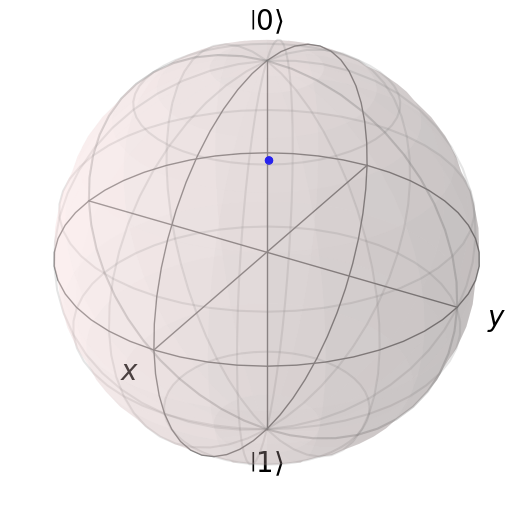

In [36]:
import numpy as np
import qutip as qt

def bloch_vector_to_density_matrix(r_vec):
    """블로흐 벡터를 밀도 행렬로 변환합니다
    입력: r_vec - [rx, ry, rz] 형태의 블로흐 벡터
    출력: density matrix (I + r·σ)/2 형태의 밀도 행렬
    """
    # 파울리 행렬들을 가져옵니다
    sx = qt.sigmax()
    sy = qt.sigmay()
    sz = qt.sigmaz()
    
    # 단위 행렬
    identity = qt.qeye(2)
    
    # 밀도 행렬 계산: rho = (I + r·σ)/2
    rho = 0.5 * (identity + r_vec[0] * sx + r_vec[1] * sy + r_vec[2] * sz)
    
    return rho

# 사용 예시
r_vec = [0.5, 0.3, 0.8]  # |r| <= 1 이어야 함
rho = bloch_vector_to_density_matrix(r_vec)

# 결과 확인
print(rho)

# 블로흐 구에 표시하기
b = qt.Bloch()
b.add_points(r_vec)
b.show()

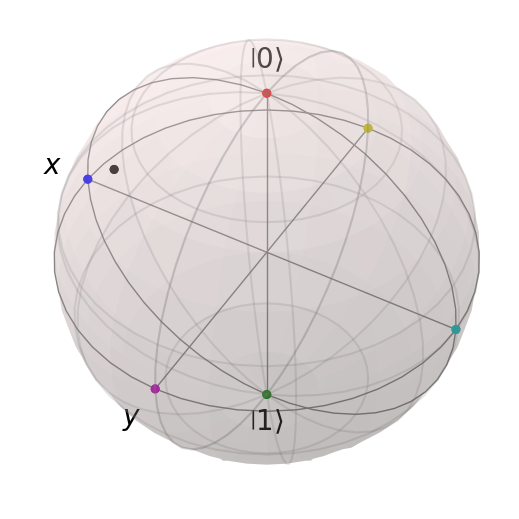

사용자 정의 밀도 행렬:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.9 +0.j   0.25-0.15j]
 [0.25+0.15j 0.1 +0.j  ]]


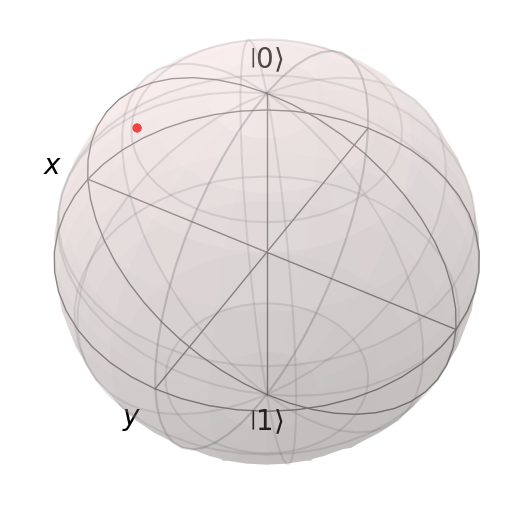

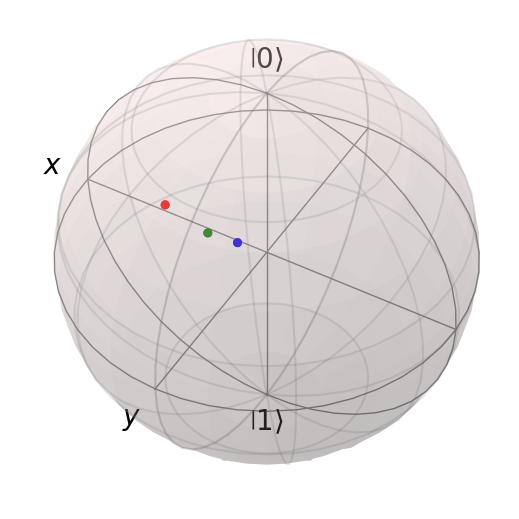

In [54]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def bloch_vector_to_density_matrix(r_vec):
    """블로흐 벡터를 밀도 행렬로 변환합니다
    입력: r_vec - [rx, ry, rz] 형태의 블로흐 벡터
    출력: density matrix (I + r·σ)/2 형태의 밀도 행렬
    """
    # 파울리 행렬들을 가져옵니다
    sx = qt.sigmax()
    sy = qt.sigmay()
    sz = qt.sigmaz()
    
    # 단위 행렬
    identity = qt.qeye(2)
    
    # 밀도 행렬 계산: rho = (I + r·σ)/2
    rho = 0.5 * (identity + r_vec[0] * sx + r_vec[1] * sy + r_vec[2] * sz)
    
    return rho

def visualize_bloch_vectors(vectors_list, labels=None, view_angles=None):
    """
    여러 블로흐 벡터를 3D로 시각화합니다.
    
    매개변수:
    vectors_list -- 시각화할 블로흐 벡터 리스트 [[rx, ry, rz], ...]
    labels -- 각 벡터에 대한 라벨 리스트 (선택 사항)
    view_angles -- 여러 각도에서 블로흐 구를 볼 수 있는 각도 리스트 (선택 사항)
                   [(elevation, azimuth), ...]
    """
    if labels is None:
        labels = [f"State {i+1}" for i in range(len(vectors_list))]
    
    if view_angles is None:
        view_angles = [(30, 45)]  # 기본 시각화 각도
    
    # 색상 리스트 (더 많은 벡터가 필요한 경우 확장할 수 있음)
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']
    
    # 각 시점에서 블로흐 구 시각화
    for angle_idx, (elev, azim) in enumerate(view_angles):
        b = qt.Bloch()
        
        # 각 벡터를 다른 색상으로 추가
        for i, vec in enumerate(vectors_list):
            color_idx = i % len(colors)
            # 수정된 부분: meth 매개변수를 's'(구)로 지정하고, colors 매개변수에 색상 전달
            b.add_points(vec, meth='s', colors=[colors[color_idx]])
        
        # 라벨 설정
        b.point_labels = labels
        
        # 블로흐 구 속성 설정
        b.point_size = [30] * len(vectors_list)  # 점 크기
        b.point_marker = ['o'] * len(vectors_list)  # 점 마커
        b.view = [elev, azim]  # 시점 각도 설정
        b.zlabel = [r'$\left|0\right>$', r'$\left|1\right>$']  # z축 라벨
        
        # 시각화
        fig_title = f"Bloch Sphere View {angle_idx+1} (Elev={elev}°, Azim={azim}°)"
        try:
            b.fig.suptitle(fig_title)
        except:
            pass  # 타이틀 설정 실패 시 무시
        
        # 렌더링 및 표시
        b.render()
        b.show()

# 예시: 다양한 상태 시각화
if __name__ == "__main__":
    # 몇 가지 예시 블로흐 벡터 (순수 상태와 혼합 상태)
    vectors = [
        [0, 0, 1],          # |0⟩ 상태 (z+)
        [0, 0, -1],         # |1⟩ 상태 (z-)
        [1, 0, 0],          # |+⟩ 상태 (x+)
        [-1, 0, 0],         # |-⟩ 상태 (x-)
        [0, 1, 0],          # |+i⟩ 상태 (y+)
        [0, -1, 0],         # |-i⟩ 상태 (y-)
        [0.5, 0.5, 0.7071]  # 혼합 상태 예시
    ]
    
    labels = ["|0⟩", "|1⟩", "|+⟩", "|-⟩", "|+i⟩", "|-i⟩", "Mixed"]
    
    # 여러 각도에서 시각화
    view_angles = [(30, 45)]
    
    visualize_bloch_vectors(vectors, labels, view_angles)
    
    # 사용자 정의 상태 시각화
    user_vector = [0.5, 0.3, 0.8]  # 사용자 정의 상태 (|r| ≤ 1 이어야 함)
    rho = bloch_vector_to_density_matrix(user_vector)
    print("사용자 정의 밀도 행렬:")
    print(rho)
    
    # 사용자 정의 상태만 별도로 시각화
    visualize_bloch_vectors([user_vector], ["사용자 정의 상태"])
    
    # 다양한 혼합 상태 시각화 (|r| < 1)
    mixed_states = [
        [0.3, 0.4, 0.5],    # |r| = 0.7071
        [0.2, 0.2, 0.2],    # |r| = 0.3464
        [0.1, 0.1, 0.1]     # |r| = 0.1732
    ]
    
    mixed_labels = [f"|r|={np.round(np.linalg.norm(v), 4)}" for v in mixed_states]
    visualize_bloch_vectors(mixed_states, mixed_labels)

In [51]:
 mixed_states = [
        [0.3, 0.4, 0.5],    # |r| = 0.7071
        [0.2, 0.2, 0.2],    # |r| = 0.3464
        [0.1, 0.1, 0.1]     # |r| = 0.1732
    ]

In [52]:
visualize_bloch_vectors(mixed_states, labels=None, view_angles=None)

ValueError: The value for meth = r is not valid. Please use 's', 'l' or 'm'.

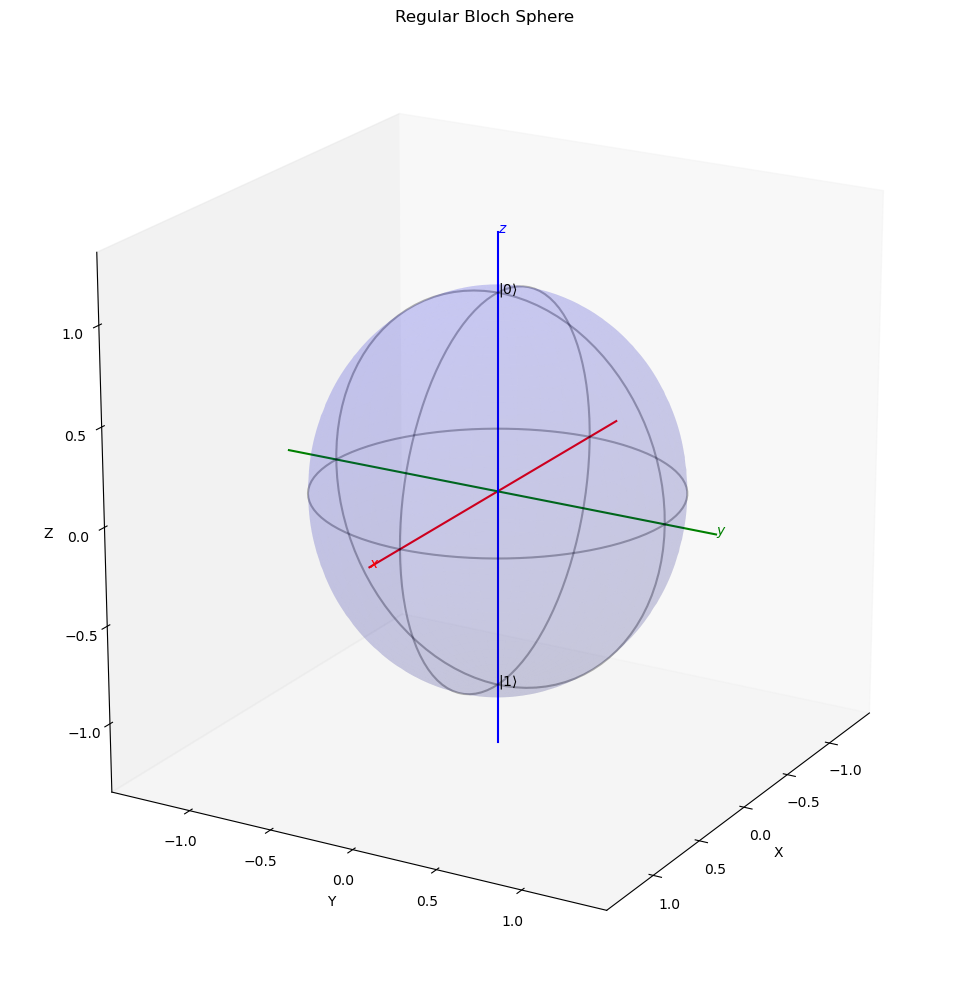

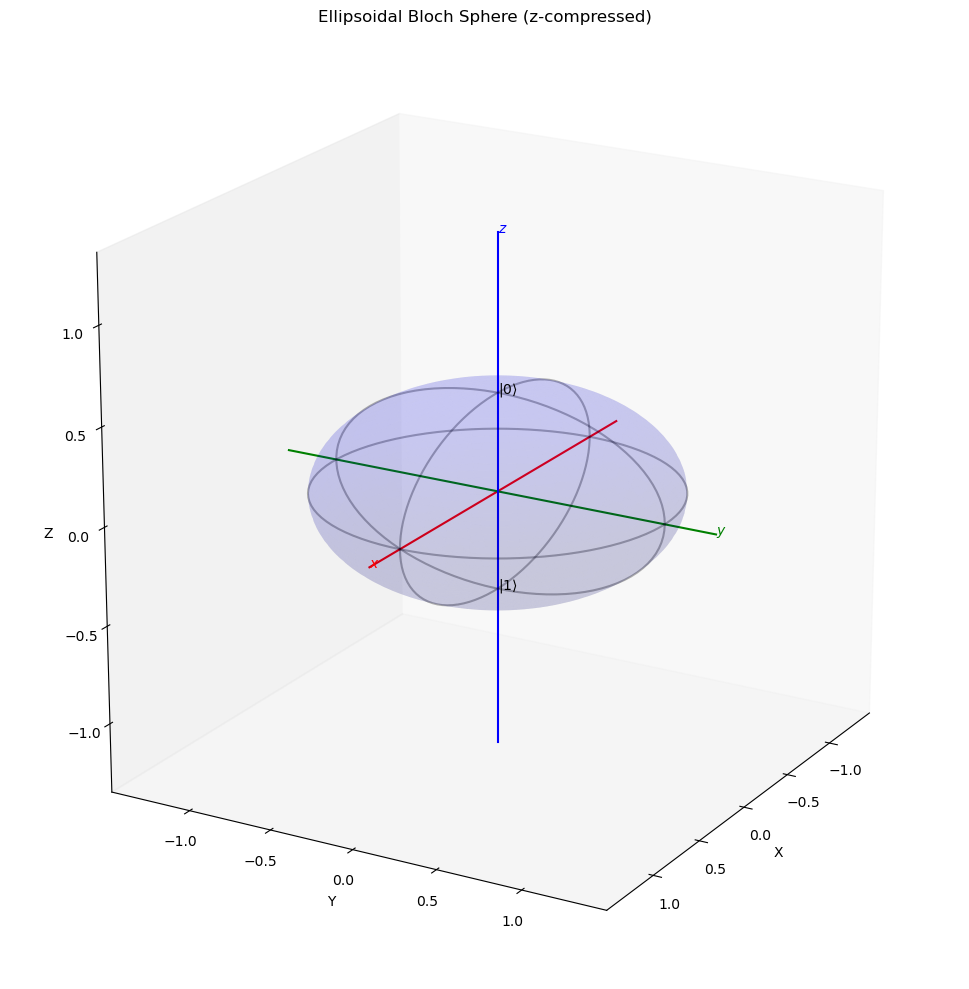

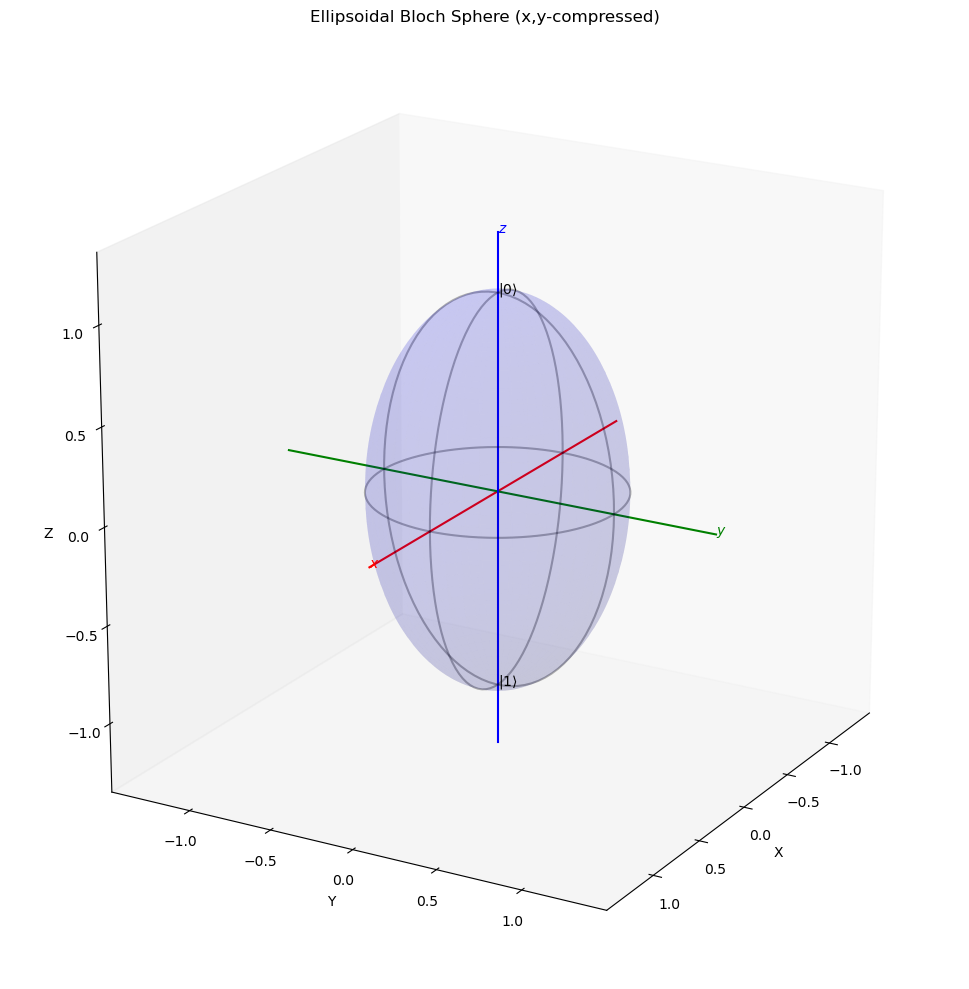

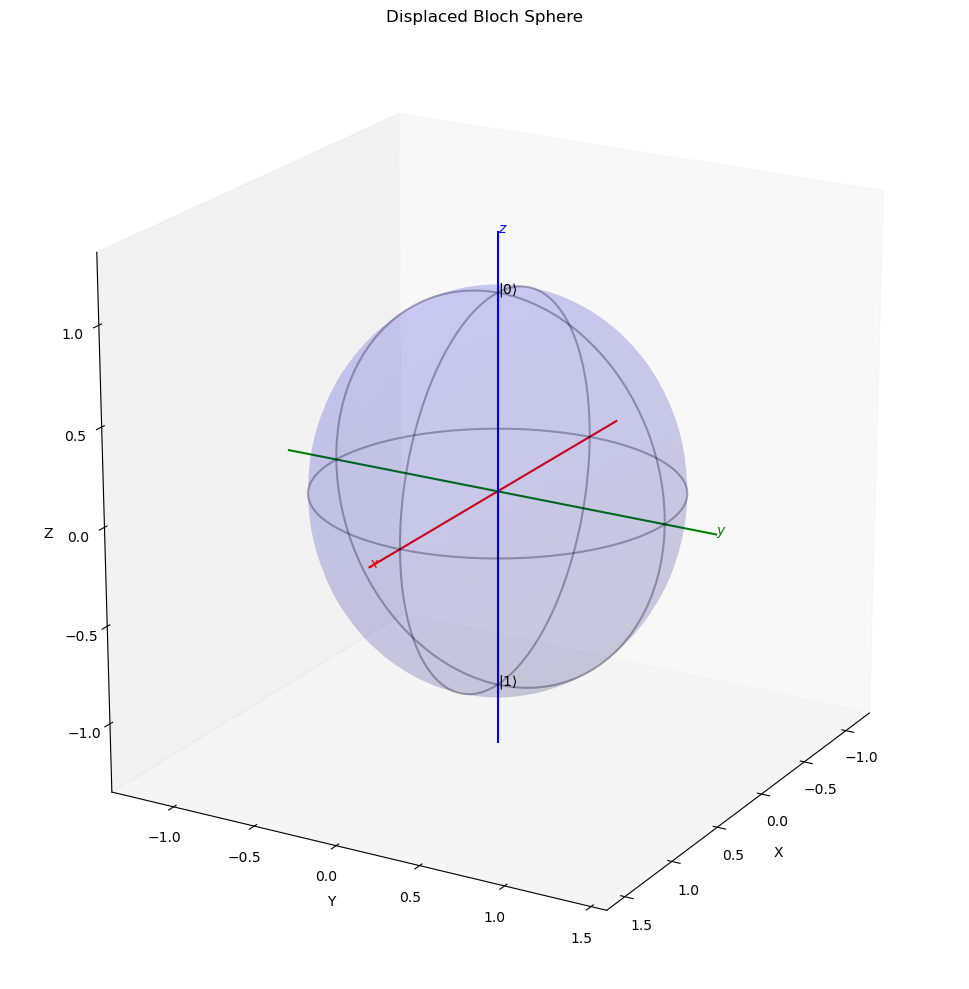

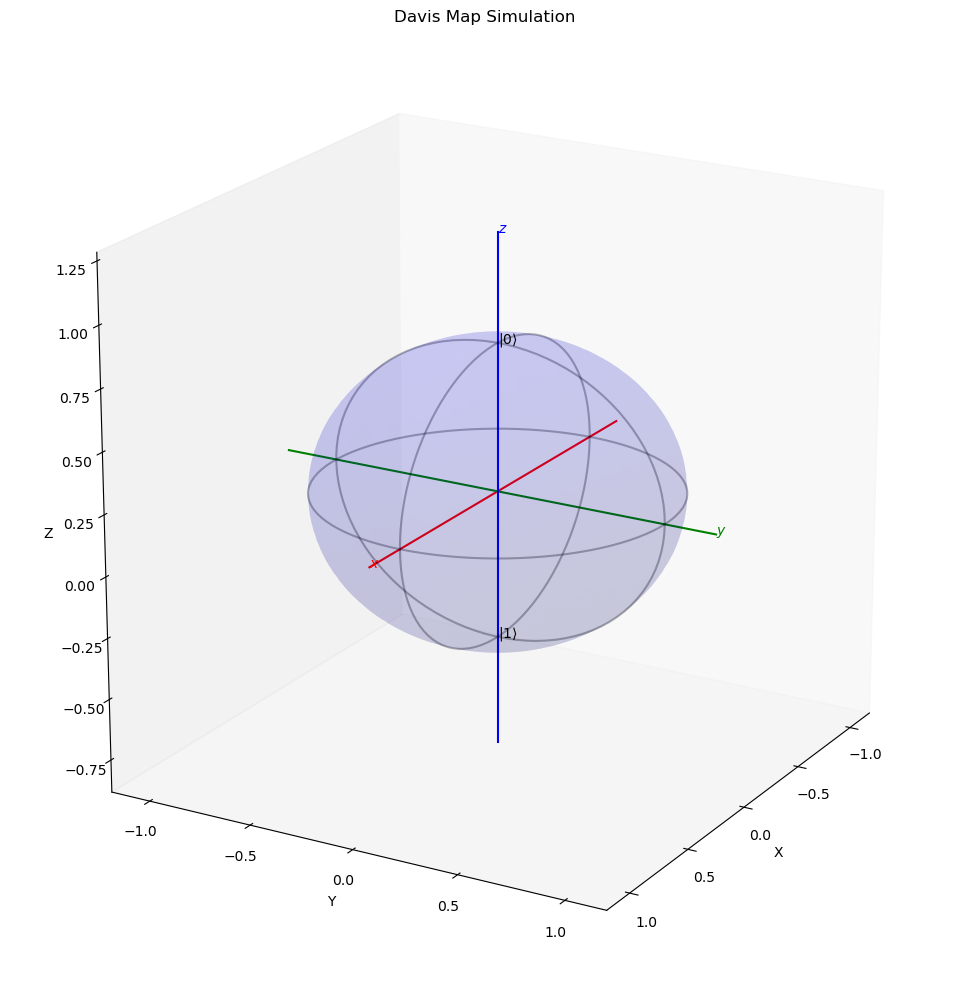

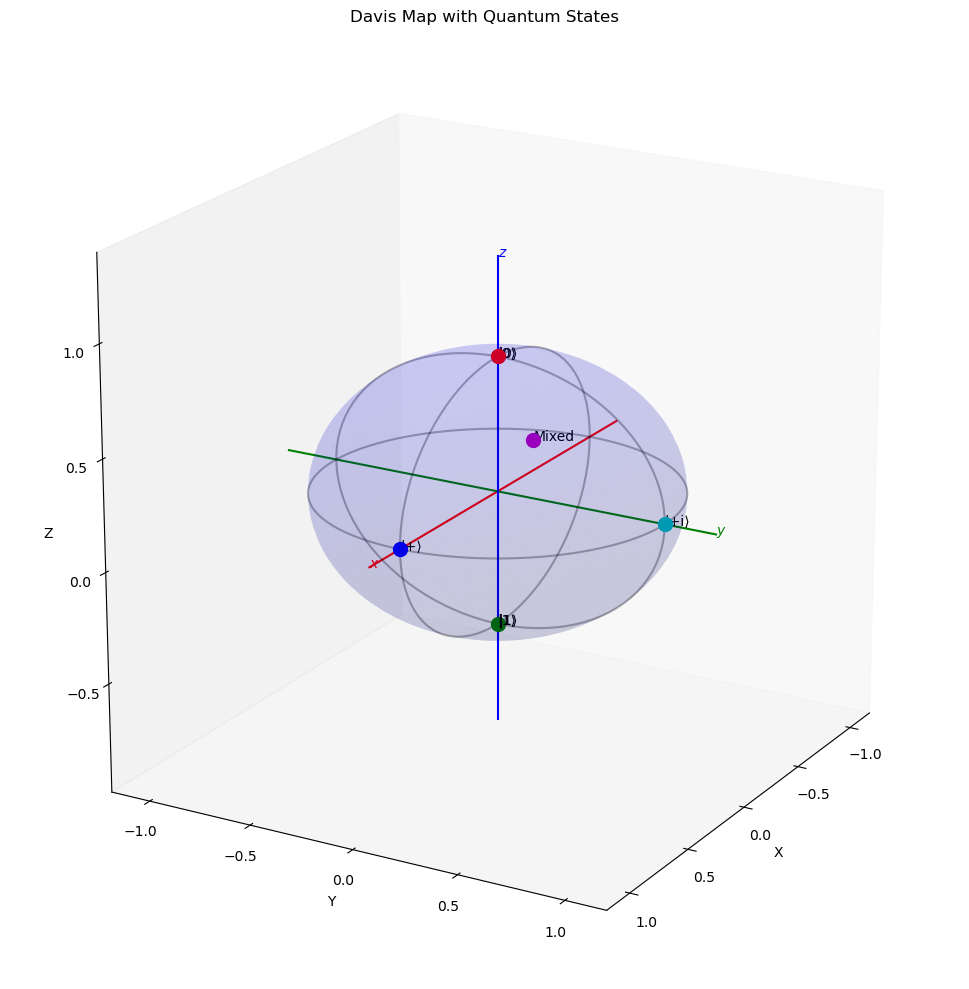

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import qutip as qt

def plot_deformed_bloch_sphere(scaling_factors=(1.0, 1.0, 1.0), displacement=(0, 0, 0), 
                               points=None, point_labels=None, title="Deformed Bloch Sphere"):
    """
    찌그러진 블로흐 구를 시각화합니다.
    
    매개변수:
    scaling_factors -- (x, y, z) 방향의 스케일링 요소 (타원체로 만듦)
    displacement -- 구의 중심 이동 (x, y, z)
    points -- 표시할 포인트 리스트 [[x, y, z], ...]
    point_labels -- 포인트 라벨
    title -- 그래프 제목
    """
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # 구를 위한 데이터 생성
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    
    # 찌그러진 구 생성 (스케일링 및 이동 적용)
    x = scaling_factors[0] * np.outer(np.cos(u), np.sin(v)) + displacement[0]
    y = scaling_factors[1] * np.outer(np.sin(u), np.sin(v)) + displacement[1]
    z = scaling_factors[2] * np.outer(np.ones(np.size(u)), np.cos(v)) + displacement[2]
    
    # 구 표면 그리기 (반투명)
    ax.plot_surface(x, y, z, color='b', alpha=0.1)
    
    # 축 선 그리기
    axes_length = 1.3 * max(scaling_factors)
    
    # x-축 (빨간색)
    ax.plot([-axes_length + displacement[0], axes_length + displacement[0]], 
            [displacement[1], displacement[1]], 
            [displacement[2], displacement[2]], 'r-')
    # y-축 (초록색)
    ax.plot([displacement[0], displacement[0]], 
            [-axes_length + displacement[1], axes_length + displacement[1]], 
            [displacement[2], displacement[2]], 'g-')
    # z-축 (파란색)
    ax.plot([displacement[0], displacement[0]], 
            [displacement[1], displacement[1]], 
            [-axes_length + displacement[2], axes_length + displacement[2]], 'b-')
    
    # 축 라벨
    ax.text(axes_length + displacement[0], displacement[1], displacement[2], r"$x$", color='r')
    ax.text(displacement[0], axes_length + displacement[1], displacement[2], r"$y$", color='g')
    ax.text(displacement[0], displacement[1], axes_length + displacement[2], r"$z$", color='b')
    
    # 상태 라벨
    ax.text(displacement[0], displacement[1], scaling_factors[2] + displacement[2], r"$|0\rangle$")
    ax.text(displacement[0], displacement[1], -scaling_factors[2] + displacement[2], r"$|1\rangle$")
    
    # 포인트 그리기
    if points is not None:
        colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']
        if point_labels is None:
            point_labels = [f"Point {i+1}" for i in range(len(points))]
        
        for i, point in enumerate(points):
            # 포인트 위치에 스케일링과 이동 적용
            scaled_point = [
                point[0] * scaling_factors[0] + displacement[0],
                point[1] * scaling_factors[1] + displacement[1],
                point[2] * scaling_factors[2] + displacement[2]
            ]
            color_idx = i % len(colors)
            ax.scatter(*scaled_point, color=colors[color_idx], s=100)
            ax.text(scaled_point[0], scaled_point[1], scaled_point[2], point_labels[i])
    
    # 경계 원 그리기
    theta = np.linspace(0, 2 * np.pi, 100)
    
    # xy-평면의 경계 원
    ax.plot(scaling_factors[0] * np.cos(theta) + displacement[0], 
            scaling_factors[1] * np.sin(theta) + displacement[1], 
            displacement[2] * np.ones_like(theta), 'k-', alpha=0.3)
    
    # xz-평면의 경계 원
    ax.plot(scaling_factors[0] * np.cos(theta) + displacement[0], 
            displacement[1] * np.ones_like(theta), 
            scaling_factors[2] * np.sin(theta) + displacement[2], 'k-', alpha=0.3)
    
    # yz-평면의 경계 원
    ax.plot(displacement[0] * np.ones_like(theta), 
            scaling_factors[1] * np.cos(theta) + displacement[1], 
            scaling_factors[2] * np.sin(theta) + displacement[2], 'k-', alpha=0.3)
    
    # 축 레이블, 제목, 그리드 설정
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    
    # 그리드 제거 (더 깔끔한 시각화를 위해)
    ax.grid(False)
    
    # 축 비율 동일하게 설정
    ax.set_box_aspect([1, 1, 1])
    
    # 시점 설정
    ax.view_init(elev=20, azim=30)
    
    plt.tight_layout()
    plt.show()

# 예제 사용
if __name__ == "__main__":
    # 일반 블로흐 구
    plot_deformed_bloch_sphere(title="Regular Bloch Sphere")
    
    # 타원형 블로흐 구 (z 방향으로 찌그러짐)
    plot_deformed_bloch_sphere(scaling_factors=(1.0, 1.0, 0.5), 
                              title="Ellipsoidal Bloch Sphere (z-compressed)")
    
    # 타원형 블로흐 구 (x, y 방향으로 찌그러짐)
    plot_deformed_bloch_sphere(scaling_factors=(0.7, 0.7, 1.0), 
                              title="Ellipsoidal Bloch Sphere (x,y-compressed)")
    
    # 이동된 중심을 가진 블로흐 구
    plot_deformed_bloch_sphere(displacement=(0.2, 0.1, 0.0), 
                              title="Displaced Bloch Sphere")
    
    # 데이비스 맵 시뮬레이션 (예시)
    plot_deformed_bloch_sphere(scaling_factors=(0.8, 0.8, 0.6), 
                              displacement=(0.0, 0.0, 0.2),
                              title="Davis Map Simulation")
    
    # 몇 가지 상태도 포함시켜 보자
    states = [
        [0, 0, 1],     # |0⟩
        [0, 0, -1],    # |1⟩
        [1, 0, 0],     # |+⟩
        [0, 1, 0],     # |+i⟩
        [0.5, 0.5, 0.7071]  # 임의의 상태
    ]
    
    labels = ["|0⟩", "|1⟩", "|+⟩", "|+i⟩", "Mixed"]
    
    # 데이비스 맵 시뮬레이션과 상태 표시
    plot_deformed_bloch_sphere(scaling_factors=(0.8, 0.8, 0.6), 
                              displacement=(0.0, 0.0, 0.2),
                              points=states,
                              point_labels=labels,
                              title="Davis Map with Quantum States")